In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
annual_data = pd.read_csv("../data/cleaned/BunkerByCategoryLong.csv")
annual_data = annual_data.set_index("year")
annual_data

,Unnamed: 0,fuel_category,bunker_sales
year,,,
1995,0,Alternative,0.00
1995,1,LNG,0.00
1995,2,LSFO,0.00
1995,3,LSMGO,0.00
1995,4,MDO,700.10
...,...,...,...
2025,243,LSMGO,4251.65
2025,244,MDO,0.00
2025,245,MFO,22085.55


In [23]:
yearly = annual_data.groupby("year")["bunker_sales"].sum().reset_index()
yearly

,year,bunker_sales
0,1995,17489.20
1,1996,16938.48
2,1997,16940.75
3,1998,18063.82
4,1999,18891.20
5,2000,18650.79
6,2001,20351.67
7,2002,20096.38
8,2003,20808.97
9,2004,23566.87


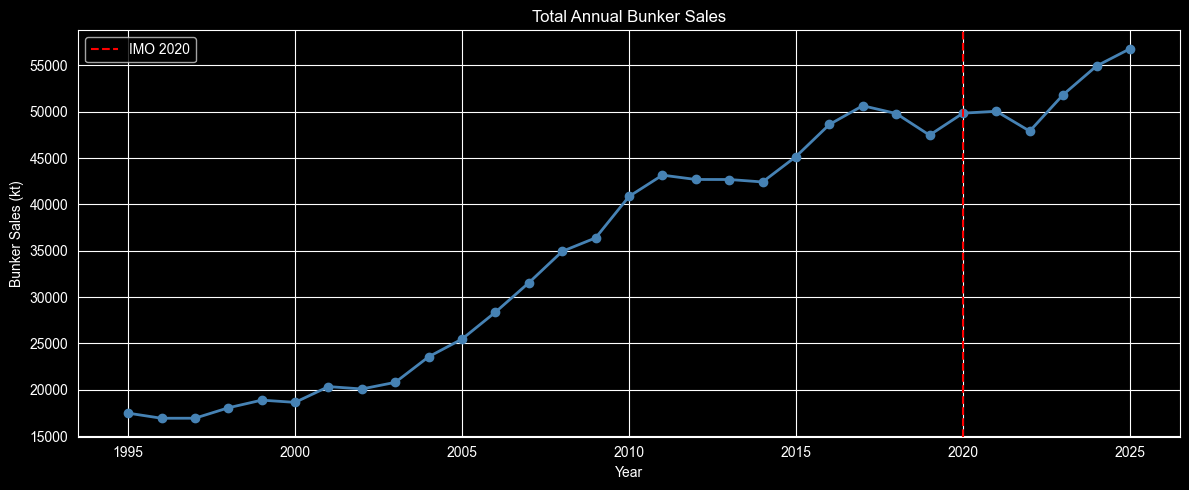

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yearly["year"], yearly["bunker_sales"], marker="o", color="steelblue", linewidth=2)
ax.axvline(2020, color="red", linestyle="--", linewidth=1.5, label="IMO 2020")
ax.set_xlabel("Year")
ax.set_ylabel("Bunker Sales (kt)")
ax.set_title("Total Annual Bunker Sales")
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
yearly["yoy_growth"] = yearly["bunker_sales"].pct_change() * 100

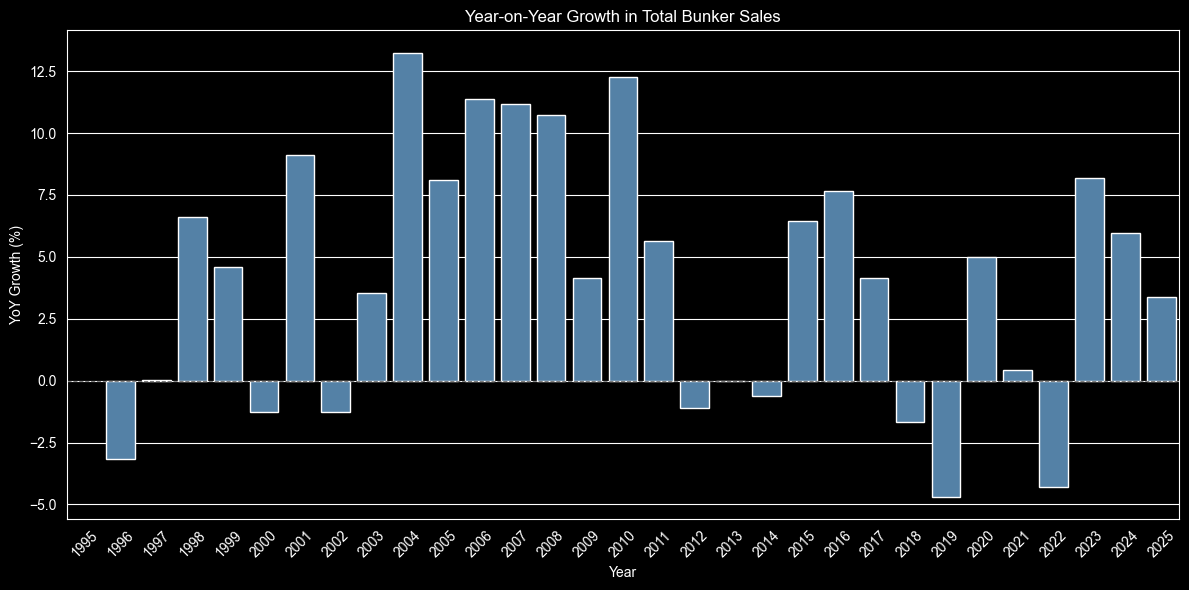

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=yearly, x="year", y="yoy_growth", ax=ax, color="steelblue")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("YoY Growth (%)")
ax.set_title("Year-on-Year Growth in Total Bunker Sales")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [27]:
annual_wide = pd.read_csv("../data/cleaned/BunkerByCategoryWide.csv")
annual_wide = annual_wide.set_index("year")

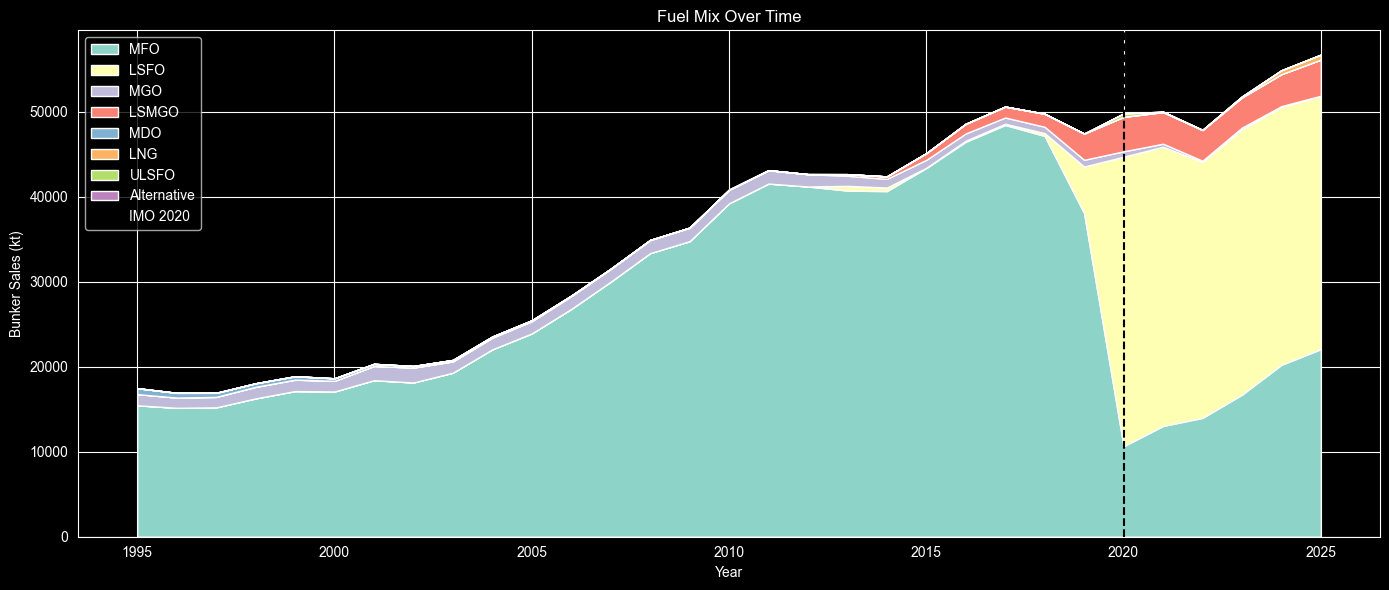

In [28]:
order = annual_wide.sum().sort_values(ascending=False).index.tolist()
fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(annual_wide.index, [annual_wide[c] for c in order], labels=order)
ax.axvline(2020, color='black', linestyle='--', linewidth=1.5, label='IMO 2020')
ax.set_xlabel('Year')
ax.set_ylabel('Bunker Sales (kt)')
ax.set_title('Fuel Mix Over Time')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


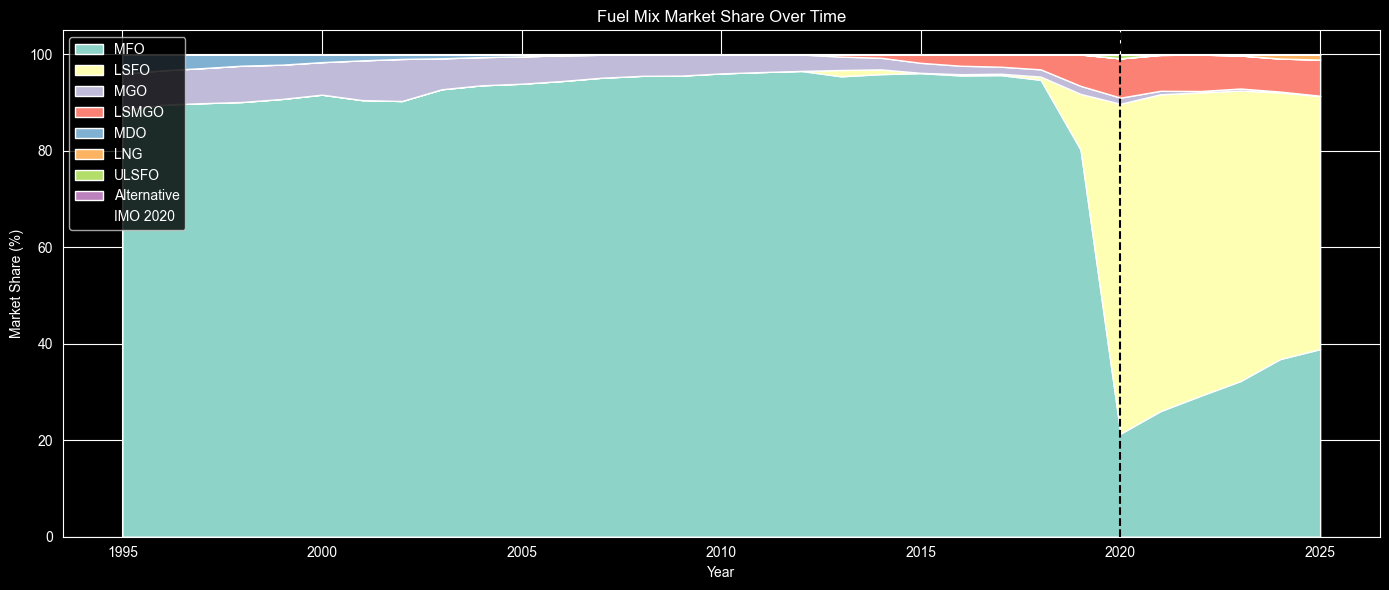

In [29]:
pct = annual_wide.div(annual_wide.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(pct.index, [pct[c] for c in order], labels=order)
ax.axvline(2020, color='black', linestyle='--', linewidth=1.5, label='IMO 2020')
ax.set_xlabel('Year')
ax.set_ylabel('Market Share (%)')
ax.set_title('Fuel Mix Market Share Over Time')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()



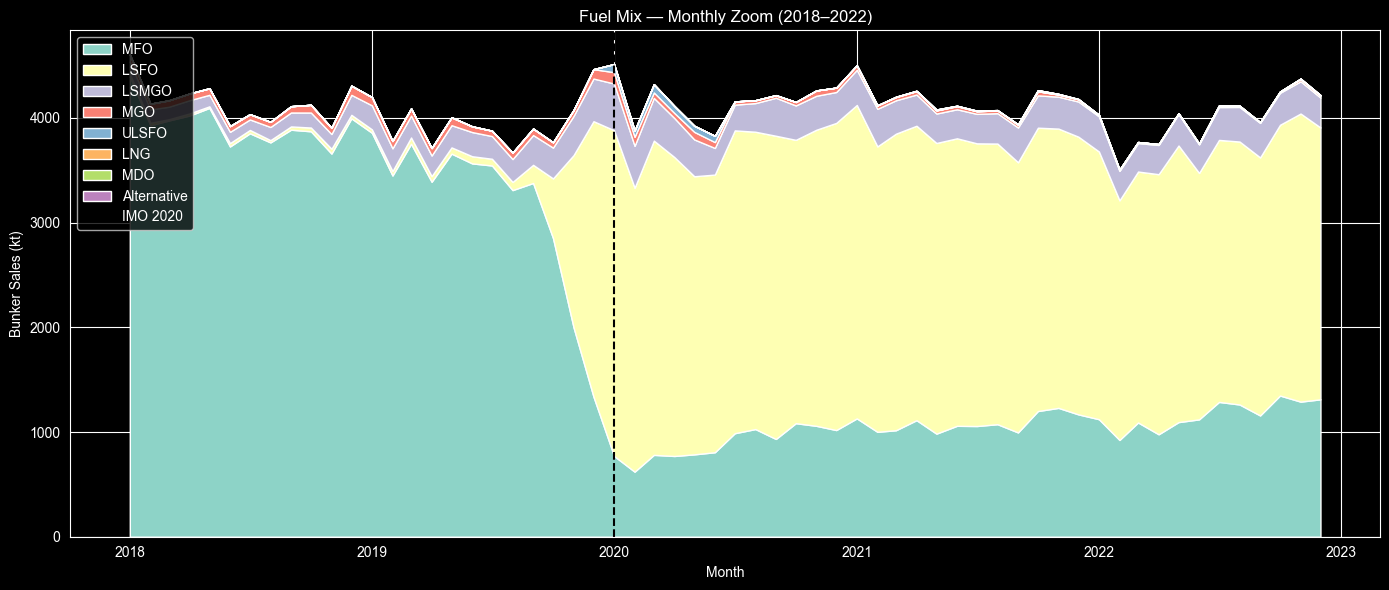

In [30]:
monthly_clean = pd.read_csv("../data/cleaned/BunkerByCategoryMonthly.csv", parse_dates=['month'])
monthly = monthly_clean.groupby(['month', 'fuel_category'])['bunker_sales'].sum().reset_index()
monthly_pivot = monthly.pivot_table(index='month', columns='fuel_category', values='bunker_sales', fill_value=0).sort_index()

zoom = monthly_pivot.loc['2018':'2022']
zoom_order = zoom.sum().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(zoom.index, [zoom[c] for c in zoom_order], labels=zoom_order)
ax.axvline(pd.Timestamp('2020-01-01'), color='black', linestyle='--', linewidth=1.5, label='IMO 2020')
ax.set_xlabel('Month')
ax.set_ylabel('Bunker Sales (kt)')
ax.set_title('Fuel Mix — Monthly Zoom (2018–2022)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


In [31]:
# CAGR for each fuel type — pre vs post IMO 2020
cagr_records = []
for fuel in annual_data["fuel_category"].unique():
    fuel_data = annual_data[annual_data["fuel_category"] == fuel].sort_index()
    annual = fuel_data.groupby(fuel_data.index)["bunker_sales"].sum()

    for period, subset in [("pre-IMO", annual[annual.index < 2020]), ("post-IMO", annual[annual.index >= 2020])]:
        subset = subset[subset > 0]
        if len(subset) > 1:
            years = subset.index[-1] - subset.index[0]
            cagr = (subset.iloc[-1] / subset.iloc[0]) ** (1 / years) - 1
            cagr_records.append({"fuel_category": fuel, "period": period, "cagr": cagr})
            print(f"{fuel} {period}: {cagr:.2%}")

cagr_df = pd.DataFrame(cagr_records)

Alternative post-IMO: 874.85%
LNG pre-IMO: 5.41%
LNG post-IMO: 84.61%
LSFO pre-IMO: 46.34%
LSFO post-IMO: -2.65%
LSMGO pre-IMO: 59.05%
LSMGO post-IMO: 0.92%
MDO pre-IMO: -24.75%
MDO post-IMO: 62.95%
MFO pre-IMO: 3.83%
MFO post-IMO: 15.70%
MGO pre-IMO: -2.10%
MGO post-IMO: -44.72%
ULSFO post-IMO: -56.11%


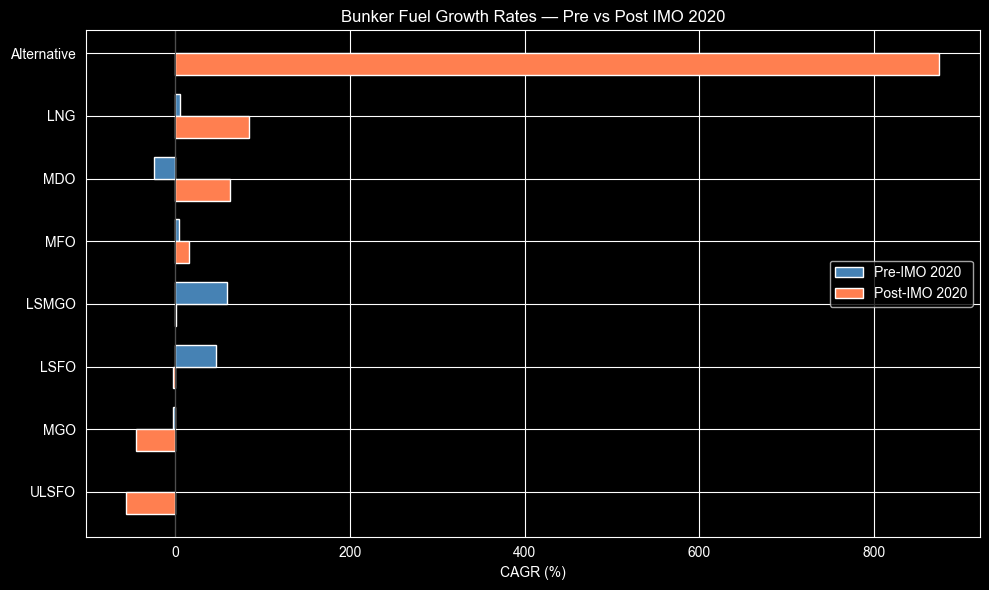

In [32]:
# Grouped horizontal bar chart — pre vs post IMO 2020 CAGR
pivot = cagr_df.pivot(index="fuel_category", columns="period", values="cagr").sort_values("post-IMO", na_position="first")

fig, ax = plt.subplots(figsize=(10, 6))
y = range(len(pivot))
bar_height = 0.35

ax.barh([i + bar_height / 2 for i in y], pivot.get("pre-IMO", pd.Series(dtype=float)).values * 100, bar_height, label="Pre-IMO 2020", color="steelblue")
ax.barh([i - bar_height / 2 for i in y], pivot.get("post-IMO", pd.Series(dtype=float)).values * 100, bar_height, label="Post-IMO 2020", color="coral")

ax.set_yticks(list(y))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("CAGR (%)")
ax.set_title("Bunker Fuel Growth Rates — Pre vs Post IMO 2020")
ax.axvline(x=0, color="black", linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.show()